<a href="https://colab.research.google.com/github/kayurh/data_analytics/blob/main/2_2_lecture_Kayur_Amour_Harry.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Lesson 2 – DataFrame Thinking (Part 2)

Last time we learned:

- how to check data quality
- how to handle missing values
- how to use groupby
- how to compute simple averages


`groupby` is not just a function.
It is a question:

- What do we compare?
- By what category?
- What does the difference tell us?

In this lesson we will:

- calculate more than one statistic
- compare groups
- look at structure
- think before we code

The goal is simple:

Not to learn more functions.
But to think like an analyst.

### The IRIS dataset

The Iris dataset is a classic dataset in the world of machine learning and data analysis. It contains 150 flower samples belonging to three different iris species (setosa, versicolor, virginica).

Each flower sample has four features:

- `sepal_len` (sepal length, cm)
- `sepal_wid` (sepal width, cm)
- `petal_len` (petal length, cm)
- `petal_wid` (petal width, cm)
- `class` (iris species name)

In [ ]:
import pandas as pd

In [ ]:
# Reading an Excel file with different parameters
df = pd.read_excel(
    "https://github.com/h2oai/h2o-2/raw/refs/heads/master/smalldata/iris/iris.xlsx",  # file path or URL
    sheet_name="iris2.csv",   # sheet name, sheet index, or a list for multiple sheets
    header=0,                 # which row to use as the header (0 = first row)
    names=None,               # if there is no header, you can provide column names here
    index_col=None,           # which column to use as the index (e.g., "ID")
    usecols=None,             # read only specific columns, e.g., "A:C" or ["Name", "Age"]
    skiprows=0,               # how many rows to skip at the start of the file
    nrows=None,               # read only a limited number of rows (e.g., nrows=100 for testing)
    dtype=None,               # set column data types (e.g., {"Age": int})
    na_values=["NA", "-"],    # custom markers for missing values
    engine="openpyxl"         # parsing engine ("openpyxl" for xlsx, "xlrd" for old xls)
)

print(df.head())

   sepal_len  sepal_wid  petal_len  petal_wid        class
0        5.1        3.5        1.4        0.2  Iris-setosa
1        4.9        3.0        1.4        0.2  Iris-setosa
2        4.7        3.2        1.3        0.2  Iris-setosa
3        4.6        3.1        1.5        0.2  Iris-setosa
4        5.0        3.6        1.4        0.2  Iris-setosa


/usr/local/lib/python3.12/dist-packages/openpyxl/worksheet/_reader.py:329: UserWarning: Unknown extension is not supported and will be removed
  warn(msg)


### Multiple aggregations at once

Let’s compute the mean and standard deviation for each column by species.

In [ ]:
df_grouped = (
       df                           # dataframe
      .groupby("class")             # group by the 'class' column
      .agg(["mean", "std"])         # compute mean and standard deviation per group
)

# Display the result.
# The output will be a DataFrame with a multi-level (MultiIndex) column structure.
display(df_grouped)

sepal_len           sepal_wid           petal_len            \
                     mean       std      mean       std      mean       std   
class                                                                         
Iris-setosa         5.006  0.352490     3.418  0.381024     1.464  0.173511   
Iris-versicolor     5.936  0.516171     2.770  0.313798     4.260  0.469911   
Iris-virginica      6.588  0.635880     2.974  0.322497     5.552  0.551895   

                petal_wid            
                     mean       std  
class                                
Iris-setosa         0.244  0.107210  
Iris-versicolor     1.326  0.197753  
Iris-virginica      2.026  0.274650

Why is it useful?

- We can see multiple statistical measures at the same time.

### Aggregating multiple columns with different statistics

For example, we can compute the mean sepal length and the maximum petal length for each species.

In [ ]:
df_grouped = (
       df
      .groupby("class")
      .agg({
          "sepal_len": "mean",
          "petal_len": "max"
      })
)

print(df_grouped)

                 sepal_len  petal_len
class                                
Iris-setosa          5.006        1.9
Iris-versicolor      5.936        5.1
Iris-virginica       6.588        6.9


Why is it useful?

- Different metrics can be applied at the same time.




### Combining `lambda` with `groupby()`

We can also use a lambda function within `groupby()` operations, for example to create custom aggregations.

### Calculating percentage difference by species

Let’s examine how the mean sepal length for each species differs from the overall mean of the dataset.

In [ ]:
df_grouped = (
    df.groupby("class")["sepal_len"].mean().apply(lambda x:
                                                         (x - df["sepal_len"].mean())       # Difference from the general average
                                                         / df["sepal_len"].mean() * 100)    # Percentage deviation
                                                        )

display(df_grouped)

,sepal_len
class,
Iris-setosa,-14.329720
Iris-versicolor,1.585853
Iris-virginica,12.743868


What is happening here?

- `groupby("class")["sepal_len"].mean()`:
  We compute the average sepal length for each species.

- `apply(lambda x: (x - global_mean) / global_mean * 100)`:
  We calculate the percentage difference compared to the overall mean of the dataset.

### Computing custom statistics by species

Let’s examine how the average petal length varies across species.

In [ ]:
df_grouped = df.groupby("class").agg(
    avg_petal_length=("petal_len", "mean"),   # 1 average petal length per species
    petal_length_category=(                  # 2 categorization based on the mean
        "petal_len",
        lambda x: "Short" if x.mean() < df["petal_len"].median() else "Long"
    )
)

display(df_grouped)

,avg_petal_length,petal_length_category
class,,
Iris-setosa,1.464,Short
Iris-versicolor,4.260,Short
Iris-virginica,5.552,Long


What is happening here?

- Mean calculation: `("petal_len", "mean")`
  → We compute the average petal length for each species.

- Categorization using a lambda function:
  → If the mean petal length of a given species is smaller than the overall median,
    we label it as "Short"; otherwise, we label it as "Long".

## Examining distributions – Raw data

So far, we have mainly computed summary statistics (mean, standard deviation).
Now we will look at the **full distribution** of the data.

We will use two tools:

- Histogram → shows the frequency of values
- KDE (Kernel Density Estimate) → a smoothed density curve

Key question:

What do we see if we **do not group** the data?
Can we observe differences between species based only on the overall distribution?

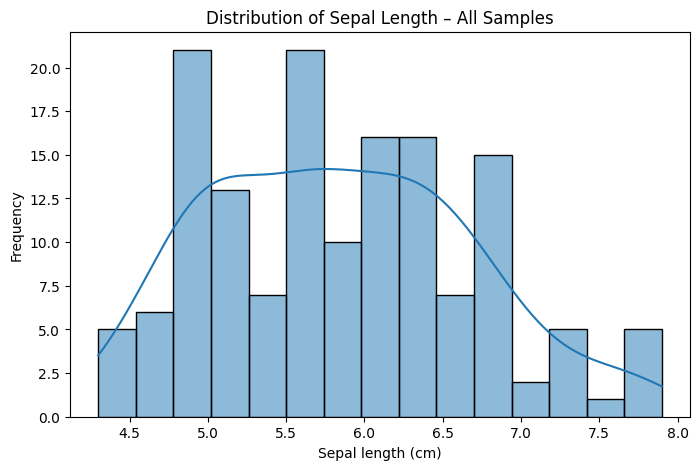

In [ ]:
import matplotlib.pyplot as plt  # Matplotlib: basic plotting library (axes, titles, figure handling)
import seaborn as sns            # Seaborn: high-level statistical plots (e.g., histogram + KDE together)

plt.figure(figsize=(8,5))        # Create a new figure with size 8×5 inches

# Create a histogram from the sepal_len column:
# - bins=15: divide the data into 15 intervals (bins)
# - kde=True: overlay a smoothed density curve (KDE) on top of the histogram
sns.histplot(df["sepal_len"], bins=15, kde=True)

plt.title("Distribution of Sepal Length – All Samples")  # Plot title
plt.xlabel("Sepal length (cm)")                          # X-axis label (with unit)
plt.ylabel("Frequency")                                  # Y-axis label (count / occurrences)

plt.show()  # Display the plot

## What does `groupby` open up?

The previous plot treated all samples together.
However, this can hide the internal structure of the data.

Now we will examine the same distribution,
but **separately by species**.

This is where the real shift in thinking happens:

We are no longer just asking:
“What does the distribution look like?”

Instead, we ask:
“How does the distribution differ across groups?”

This is the point where `groupby`
is no longer just a technical tool,
but an analytical perspective.

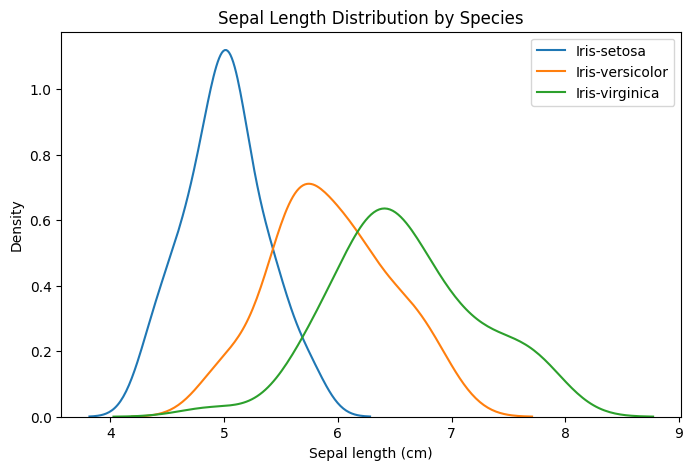

In [ ]:
plt.figure(figsize=(8,5))  # Create a new figure with size 8×5 inches

# Iterate through all unique species names (class categories)
for species in df["class"].unique():
    # Select rows belonging to the given species (subset)
    subset = df[df["class"] == species]

    # Plot the KDE curve for the sepal_len distribution of that species
    # label=species: this name will appear in the legend
    sns.kdeplot(subset["sepal_len"], label=species)

plt.title("Sepal Length Distribution by Species")  # Plot title
plt.xlabel("Sepal length (cm)")                    # X-axis label (with unit)
plt.ylabel("Density")                              # Y-axis: density (not count, but estimated distribution)
plt.legend()                                       # Show legend (which curve belongs to which species)

plt.show()  # Display the plot

### What did we learn from this?

- The overall distribution did not clearly reveal the differences between species.
- After grouping, the internal structure became visible.
- `groupby` is not just about calculation —
  it is about **decomposing the data into different perspectives**.

This way of thinking is the foundation of later modeling:
if we do not see the group structure,
the model will not see it either.


## Single-key grouping – What do the averages tell us?

Let’s start with a simple question:

Is there a difference between the three iris species
in terms of sepal length (`sepal_len`)?

Using `groupby`, we compute for each species:

- the mean,
- the standard deviation,
- the sample size.

Important:
The mean alone can be misleading.
Always examine the standard deviation and the sample size as well.

In [ ]:
# Group by 'class', then compute aggregations:
# - mean_sepal: mean of sepal_len per species
# - std_sepal: standard deviation of sepal_len per species
# - count: sample size per species (size = number of rows in the group)
df_single = (
    df.groupby("class")
      .agg(
          mean_sepal=("sepal_len", "mean"),
          std_sepal=("sepal_len", "std"),
          count=("sepal_len", "size")
      )
      .reset_index()  # Move 'class' from the index back to a regular column (easier for further processing/plotting)
)

display(df_single)  # Display the result in a formatted table (nicely rendered in Jupyter)

,class,mean_sepal,std_sepal,count
0,Iris-setosa,5.006,0.352490,50
1,Iris-versicolor,5.936,0.516171,50
2,Iris-virginica,6.588,0.635880,50


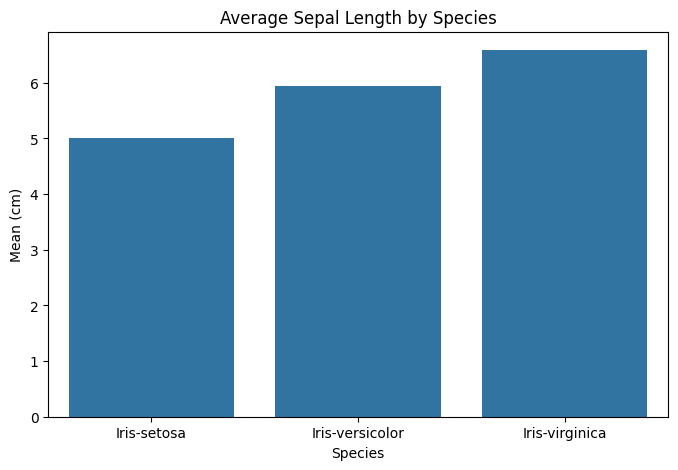

In [ ]:
plt.figure(figsize=(8,5))  # Create a new figure with size 8×5 inches

# Create a bar plot:
# - x-axis: species (class)
# - y-axis: mean sepal length per species (mean_sepal), previously computed in df_single
sns.barplot(data=df_single, x="class", y="mean_sepal")

plt.title("Average Sepal Length by Species")  # Plot title
plt.ylabel("Mean (cm)")                       # Y-axis label (mean value in cm)
plt.xlabel("Species")                         # X-axis label (categories: species)

plt.show()  # Display the plot

What do we see?

- The mean of *setosa* is smaller.
- *virginica* shows larger values.
- *versicolor* is in between.

This is already an analytical statement:
There is a structural difference between the species.

But do all samples behave the same way?

## Multi-level grouping – What happens if we consider multiple dimensions?

Now we do not only consider the species,
but we also categorize the petal length.

Question:

If petal length differs within a species,
does sepal length change as well?

Here we group by two keys:

- `class`
- `petal_size`

This creates a MultiIndex structure.

In [ ]:
# Define bin boundaries (intervals) based on petal_len
# - 0: lower bound (safe minimum)
# - 4.5: upper bound of the first category
# - 4.9: upper bound of the second category
# - df["petal_len"].max(): upper bound of the third category (up to the maximum value)
bins = [0, 4.5, 4.9, df["petal_len"].max()]

# Labels for the intervals (3 intervals → 3 labels)
labels = ["small", "medium", "large"]

# Use pd.cut to assign numeric petal_len values into categories:
# Each row receives a "petal_size" category depending on
# which bin interval the petal_len value falls into.
df["petal_size"] = pd.cut(
    df["petal_len"],  # numeric column to categorize
    bins=bins,        # interval boundaries
    labels=labels     # category names assigned to intervals
)

df.head()  # Check: the new petal_size column appears in the first few rows

,sepal_len,sepal_wid,petal_len,petal_wid,class,petal_size
0,5.1,3.5,1.4,0.2,Iris-setosa,small
1,4.9,3.0,1.4,0.2,Iris-setosa,small
2,4.7,3.2,1.3,0.2,Iris-setosa,small
3,4.6,3.1,1.5,0.2,Iris-setosa,small
4,5.0,3.6,1.4,0.2,Iris-setosa,small


In [ ]:
# Multi-level (multi-key) grouping:
# - 1st key: class (iris species)
# - 2nd key: petal_size (the previously created petal length category)
#
# This means the DataFrame is split into groups based on "species × category" combinations.
df_multi = (
    df.groupby(["class", "petal_size"])
      .agg(
          mean_sepal=("sepal_len", "mean"),  # mean of sepal_len for each (class, petal_size) group
          count=("sepal_len", "size")        # sample size for each (class, petal_size) group
      )
)

# Display:
# The result has a two-level index (MultiIndex): (class, petal_size),
# meaning rows are identified by group labels instead of a simple 0..N index.
display(df_multi)

/tmp/ipython-input-3374908042.py:7: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby(["class", "petal_size"])


mean_sepal  count
class           petal_size                   
Iris-setosa     small         5.006000     50
                medium             NaN      0
                large              NaN      0
Iris-versicolor small         5.744444     36
                medium        6.441667     12
                large         6.350000      2
Iris-virginica  small         4.900000      1
                medium        6.040000      5
                large         6.688636     44

What do we see?

The result now contains a two-level index:

- (`class`, `petal_size`)

This means the grouping has created
a hierarchical structure.

This is not just more data,
but more perspectives.

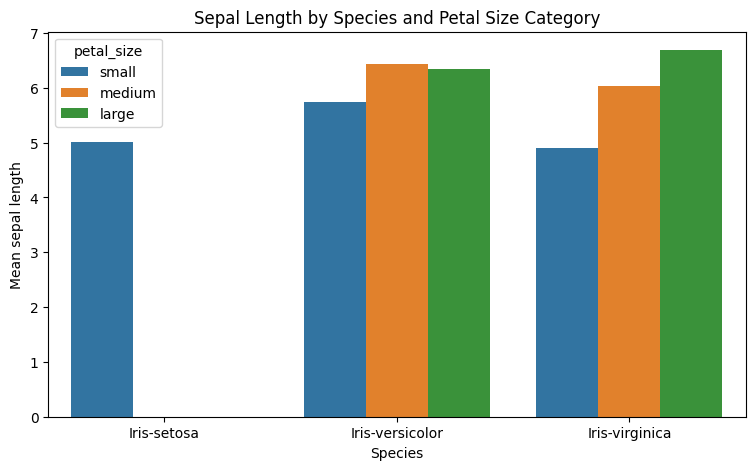

In [ ]:
# df_multi is a MultiIndex DataFrame (index: class + petal_size).
# reset_index() converts the index levels back into regular columns,
# which makes visualization easier (Seaborn usually expects data in this format).
df_multi_reset = df_multi.reset_index()

plt.figure(figsize=(9,5))  # Create a new figure (slightly wider, since we have multiple categories)

# Create a bar plot:
# - x-axis: class (species)
# - y-axis: mean_sepal (average sepal_len within each group)
# - hue: petal_size (different colors represent petal length categories within each species)
sns.barplot(
    data=df_multi_reset,
    x="class",
    y="mean_sepal",
    hue="petal_size"
)

plt.title("Sepal Length by Species and Petal Size Category")  # Plot title
plt.ylabel("Mean sepal length")                                # Y-axis label (mean value)
plt.xlabel("Species")                                          # X-axis label (species)

plt.show()  # Display the plot

What did we gain from multi-level grouping?

- We not only see that the species differ.
- We also see that there is structure within each species.
- Petal length becomes an additional explanatory variable.

This is the foundation of analytical thinking:

We do not examine the data from a single perspective,
but across multiple dimensions.

The MultiIndex is therefore not a technical curiosity,
but a structured viewpoint.

### Exercises

Load the TITANIC dataset.

In [ ]:
# Loading the Titanic dataset using scikit-learn

from sklearn.datasets import fetch_openml
import pandas as pd

# Load the dataset from the OpenML repository
titanic = fetch_openml(name="titanic", version=1, as_frame=True)

# Convert the data to a pandas DataFrame
df = titanic.data
df["survived"] = titanic.target  # Attach the target variable (y) as well
df["survived"] = df["survived"].astype('int64')

### Exercise 1 – Bar chart

- Group the data by `pclass` and `sex`.
- For each group, compute:
  - `survival_rate` (mean of `survived`)
  - `passenger_count` (`size`)
- After `reset_index()`, create a bar chart:
  - x-axis: `pclass`
  - y-axis: `survival_rate`
  - hue: `sex`

Which group has the highest survival rate?

/tmp/ipykernel_28434/2132727198.py:11: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  g = df.groupby(['pclass','sex']).agg(survival_rate=('survived','mean'), passenger_count=('survived','size')).reset_index()


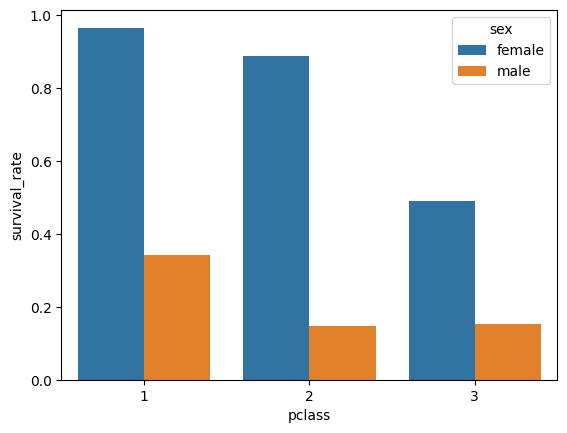

pclass                    1
sex                  female
survival_rate      0.965278
passenger_count         144
Name: 0, dtype: object


In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_openml

titanic = fetch_openml(name='titanic', version=1, as_frame=True)
df = titanic.frame

df['survived'] = pd.to_numeric(df['survived'], errors='coerce')

g = df.groupby(['pclass','sex']).agg(survival_rate=('survived','mean'), passenger_count=('survived','size')).reset_index()

sns.barplot(data=g, x='pclass', y='survival_rate', hue='sex')
plt.show()

print(g.loc[g['survival_rate'].idxmax()])

### Exercise 2 – Age group × gender → survival rate (visualization)

Goal: `pd.cut` (or `apply`) + multi-index `groupby` + barplot

- Create an `age_group` column based on `age`:
  - `child`: 0–12  
  - `adult`: 13–59  
  - `senior`: 60+  
  - missing `age` → `unknown`
- Group the data by `age_group` and `sex`.
- Compute:
  - `survival_rate` = mean of `survived`
  - `passenger_count` = `size`
- Visualize with a barplot:
  - x-axis: `age_group`
  - y-axis: `survival_rate`
  - hue: `sex`

In which age group is the difference between male and female survival the largest?

/tmp/ipykernel_28434/240162207.py:14: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  g = df.groupby(['age_group','sex']).agg(survival_rate=('survived','mean'), passenger_count=('survived','size')).reset_index()


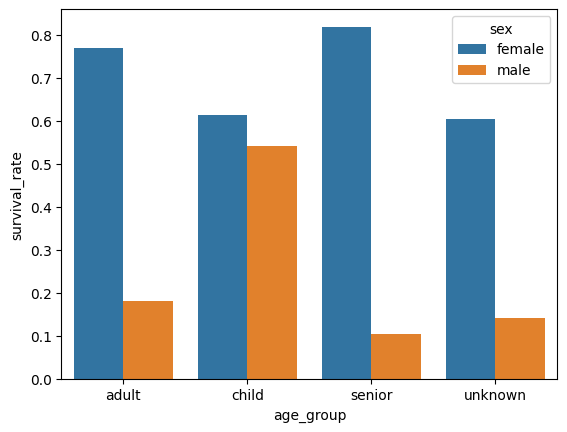

senior


In [2]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_openml

titanic = fetch_openml(name='titanic', version=1, as_frame=True)
df = titanic.frame

df['age'] = pd.to_numeric(df['age'], errors='coerce')
df['survived'] = pd.to_numeric(df['survived'], errors='coerce')

df['age_group'] = df['age'].apply(lambda x: 'unknown' if pd.isna(x) else ('child' if x <= 12 else ('adult' if x <= 59 else 'senior')))

g = df.groupby(['age_group','sex']).agg(survival_rate=('survived','mean'), passenger_count=('survived','size')).reset_index()

sns.barplot(data=g, x='age_group', y='survival_rate', hue='sex')
plt.show()

pivot = g.pivot(index='age_group', columns='sex', values='survival_rate')
diff = (pivot['female'] - pivot['male']).abs()
print(diff.idxmax())